# 02 — La rupture de collecte du 13 mars 2026

**Objectif** — expliquer le pic de volume de mars-avril 2026 avant de l'interpréter.

| | |
|---|---|
| **Entrée** | export Intercom (via `chargement`) |
| **Sorties** | `resultats/tables/02_completude_mensuelle.csv`, `02_bascule_quotidienne.csv` + 3 figures |
| **Suite** | notebook 03 — définition du périmètre d'analyse |

**Ce que ce notebook établit**

Le pic de réclamations de mars-avril 2026 est **contemporain d'une panne de
capture des champs du formulaire**, pas d'un incident produit isolé. Le 13 mars,
la part de tickets sans aucun contenu passe de moins de 10 % à 80 %, puis 100 %
en 48 heures. Tous les champs de saisie tombent ensemble et reviennent ensemble.

Cette conclusion contredit une lecture courante de ces données (« incident SARA
de mars-avril »). La démonstration est donc conduite pas à pas.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)

df = chargement.typer(chargement.charger_brut())
print(f"{len(df):,} tickets chargés")

18,094 tickets chargés


## 1. Deux régimes : phase pilote et période opérationnelle

Premier constat, préalable à tout : le canal n'a un volume significatif que
depuis novembre 2025.

In [2]:
mensuel = df.groupby("mois").size()
print(f"Avant novembre 2025 : {mensuel[mensuel.index < '2025-11'].sum()} tickets sur 21 mois")
print(f"À partir de novembre 2025 : {mensuel[mensuel.index >= '2025-11'].sum():,} tickets sur 9 mois")

Avant novembre 2025 : 38 tickets sur 21 mois
À partir de novembre 2025 : 18,056 tickets sur 9 mois


Les 38 tickets antérieurs ne sont pas une activité commerciale ralentie. Le test
qui tranche est la **répartition par canal de part et d'autre de la bascule** :
si le dispositif était le même avec moins de volume, la répartition serait
comparable. Elle ne l'est pas du tout.

In [3]:
avant = df[df["date_creation"] < config.DEBUT_PERIODE_OPERATIONNELLE]
apres = df[df["date_creation"] >= config.DEBUT_PERIODE_OPERATIONNELLE]

canaux = pd.DataFrame(
    {
        "avant_pct": avant["channel"].value_counts(normalize=True) * 100,
        "apres_pct": apres["channel"].value_counts(normalize=True) * 100,
    }
).fillna(0).round(1)
canaux

,avant_pct,apres_pct
channel,,
android,13.2,65.7
email,2.6,0.0
facebook,21.1,1.0
instagram,0.0,0.0
ios,21.1,20.6
messenger,42.1,0.0
whatsapp,0.0,12.7


`whatsapp`, troisième canal après le lancement, **n'existe pas** avant. À
l'inverse `messenger`, qui pèse 42 % avant, devient résiduel. Ce n'est pas une
montée en charge : c'est un dispositif différent. La période antérieure à
novembre 2025 est donc écartée de toute analyse de tendance.

In [4]:
op = chargement.perimetre_operationnel(df)
print(f"Période opérationnelle : {len(op):,} tickets")

Période opérationnelle : 18,056 tickets


## 2. Le pic de mars-avril 2026

Sur la période opérationnelle, le volume mensuel n'est pas stable : il triple
en mars-avril avant de retomber.

  -> resultats\figures\02_volume_mensuel.png


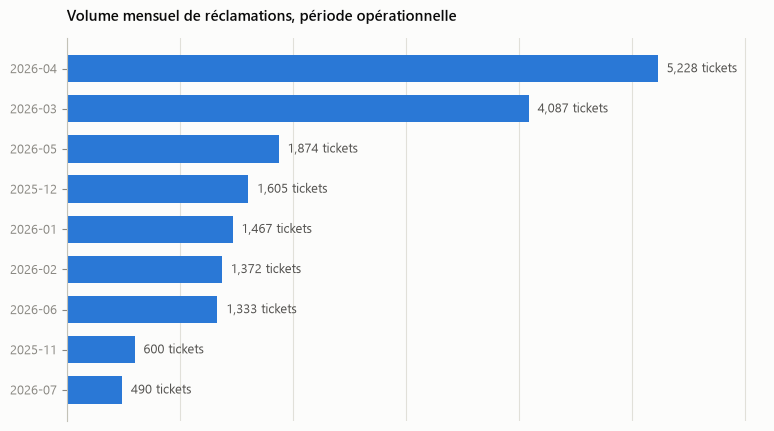

In [5]:
vol = op.groupby("mois").size()
ax = viz.barres_horizontales(
    vol.sort_index(ascending=False).rename(index=str),
    "Volume mensuel de réclamations, période opérationnelle",
    unite=" tickets",
)
viz.sauver(ax.figure, "02_volume_mensuel")
plt.show()

C'est ce pic qui est habituellement lu comme un incident produit. Avant de
l'interpréter, une vérification élémentaire : **est-ce que ces tickets
ressemblent aux autres ?**

## 3. Le test décisif : la complétude des champs dans le temps

On mesure le taux de remplissage de quatre champs indépendants les uns des
autres — un texte libre saisi par le client, un montant, une agence, un titre.
S'il s'agissait d'un afflux de vraies réclamations, ces champs resteraient
remplis comme avant.

In [6]:
CHAMPS = [
    "ticket_attributes__default_description_",
    "ticket_attributes_Montant en XAF",
    "ticket_attributes_Agence",
    "ticket_attributes__default_title_",
]
completude = chargement.taux_completude(op, CHAMPS)
completude.columns = ["description", "montant", "agence", "titre", "nb_tickets"]
chargement.sauver_table(completude.round(3), "02_completude_mensuelle")
completude.round(2)

  -> resultats\tables\02_completude_mensuelle.csv


,description,montant,agence,titre,nb_tickets
mois,,,,,
2025-11,0.99,0.94,0.95,0.50,600
2025-12,1.00,0.95,0.99,0.74,1605
2026-01,1.00,0.94,0.99,0.67,1467
2026-02,0.99,0.92,0.96,0.74,1372
2026-03,0.16,0.13,0.14,0.11,4087
2026-04,0.03,0.03,0.03,0.02,5228
2026-05,0.30,0.22,0.24,0.17,1874
2026-06,0.99,0.81,0.86,0.53,1333
2026-07,0.99,0.68,0.72,0.60,490


**Le résultat est sans ambiguïté.** Les quatre champs sont remplis à 92-99 %
jusqu'en février, s'effondrent ensemble à 3-16 % sur mars-avril, et remontent
ensemble à 92-93 % en juin.

Quatre champs de nature différente, alimentés à des moments différents du
parcours, ne disparaissent pas simultanément par hasard. Aucun afflux de
réclamations ne produit cet effet : un client qui se plaint écrit son problème.

## 4. Volume et complétude, côte à côte

On empile les deux mesures sur un axe temporel partagé plutôt que de les
superposer sur deux échelles : un volume et un taux ne se comparent pas sur le
même graphique sans que le choix des échelles décide de la conclusion.

  -> resultats\figures\02_volume_et_completude.png


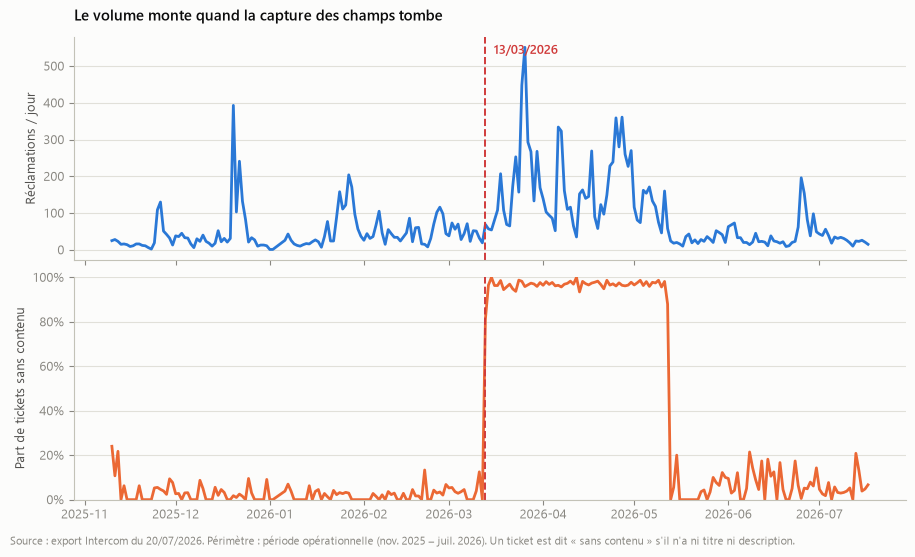

In [7]:
quotidien = op.groupby("jour").agg(
    volume=("id", "size"),
    part_vide=("id", "size"),
)
quotidien["part_vide"] = op.assign(vide=chargement.indicateur_ticket_vide(op)).groupby("jour")[
    "vide"
].mean()
quotidien.index = pd.to_datetime(quotidien.index)

fig, axes = viz.panneaux_temporels(
    quotidien.index,
    [
        {
            "valeurs": quotidien["volume"],
            "libelle": "Réclamations / jour",
            "couleur": viz.SERIES[0],
            "type": "ligne",
        },
        {
            "valeurs": quotidien["part_vide"],
            "libelle": "Part de tickets sans contenu",
            "couleur": viz.SERIES[1],
            "type": "ligne",
            "pct": True,
        },
    ],
    titre="Le volume monte quand la capture des champs tombe",
    ligne_verticale=config.DATE_RUPTURE_COLLECTE,
    etiquette_ligne="13/03/2026",
)
viz.annoter_source(
    fig,
    "Source : export Intercom du 20/07/2026. Périmètre : période opérationnelle "
    "(nov. 2025 – juil. 2026). Un ticket est dit « sans contenu » s'il n'a ni titre ni description.",
)
viz.sauver(fig, "02_volume_et_completude")
plt.show()

## 5. Datation précise de la bascule

Le passage se fait en 48 heures, ce qui exclut une dérive progressive du
comportement des agents ou des clients.

In [8]:
bascule = quotidien.loc["2026-03-08":"2026-03-18"].copy()
bascule["part_vide"] = (bascule["part_vide"] * 100).round(0)
chargement.sauver_table(bascule, "02_bascule_quotidienne")
bascule

  -> resultats\tables\02_bascule_quotidienne.csv


,volume,part_vide
jour,,
2026-03-08,23,0.0
2026-03-09,52,0.0
2026-03-10,51,4.0
2026-03-11,32,12.0
2026-03-12,19,0.0
2026-03-13,69,81.0
2026-03-14,57,96.0
2026-03-15,54,100.0
2026-03-16,81,96.0


## 6. Retour à la normale

La symétrie est le second argument : si le phénomène était un afflux de
réclamations, sa fin n'aurait aucune raison de coïncider avec le retour des champs.

In [9]:
retour = quotidien.loc["2026-05-15":"2026-06-15", ["volume", "part_vide"]].copy()
retour["part_vide"] = (retour["part_vide"] * 100).round(0)
retour.head(15)

,volume,part_vide
jour,,
2026-05-15,20,20.0
2026-05-16,16,0.0
2026-05-17,10,0.0
2026-05-18,36,0.0
2026-05-19,43,0.0
2026-05-20,19,0.0
2026-05-21,27,0.0
2026-05-22,17,0.0
2026-05-23,28,4.0


## 7. Conclusion du notebook

| Observation | Compatible avec un incident produit ? | Compatible avec une mise en production ? |
|---|---|---|
| Volume ×3 sur mars-avril | oui | oui |
| Description, montant, agence et titre tombent **ensemble** | non | oui |
| Bascule en 48 h (9 % → 100 %) | non | oui |
| Champs et volume reviennent **ensemble** à la normale | non | oui |

> **Hypothèse retenue** — un changement déployé autour du 13-16 mars 2026 sur
> l'application ou sur le flux Intercom a simultanément (a) cessé d'alimenter
> les attributs du ticket et (b) modifié le parcours de dépôt d'une réclamation.
>
> **À faire confirmer** par l'équipe produit : historique des mises en production
> sur la période, et modification de configuration du workspace Intercom. Ce
> notebook établit la concomitance, pas le mécanisme.

**Conséquence méthodologique immédiate** : les 11 189 tickets de mars-mai 2026
ne peuvent pas servir à comprendre pourquoi les clients se plaignent — ils ne
contiennent pas ce que les clients ont écrit. C'est l'objet du notebook 03 de
vérifier si le peu qui subsiste dans cette fenêtre est malgré tout exploitable.